# RSA between task features and model activations

In [20]:
import numpy as np
import pandas as pd

n_layer = 4
seeds = [2235, 6312, 6068, 9742, 8880, 2197, 669,
         6256, 3309, 2541, 8643, 7785, 195, 6914, 29]
rdm_method_ann = "euclidean"
pe_desc = "2dpe"
epoch = 4000

In [21]:
import rsatoolbox

def create_transformer_ds_from_ann(weights, n_layer, seeds):
    ds_list = []
    for ann_label in ["pe", "attn_out", "mlp"]:
        for layer in range(n_layer):
            for seed in range(len(seeds)):
                data = weights[ann_label][seed, layer]
                des = {'model': ann_label, "layer": layer, "seed":seed}

                # generate information for puzzles, conditions and seeds
                puzzles = np.arange(1, 109)

                obs_des = {'puzzles': puzzles}

                ds = rsatoolbox.data.Dataset(measurements=data,
                                                descriptors=des,
                                                obs_descriptors=obs_des
                                                )
                ds_list.append(ds)
    return ds_list

In [22]:

from lstnn.dataset import get_dataset
from lstnn.compare_rdms import get_transformer_weights
from lstnn.task_features import get_experimentor_rdms
import rsatoolbox

# read in ANN activations
# load test puzzles as a torch ds
LST_puzzle_ds = get_dataset("../processed_data/puzzle_data_original.csv")

# Get task RDMS
task_rdms = get_experimentor_rdms(LST_puzzle_ds)

# Combine into a list of rsatoolbox models
models = []
for rdm in task_rdms:
    label = rdm.rdm_descriptors['name'][0]
    m = rsatoolbox.model.ModelFixed(label, rdm)
    models.append(m)

# Get specified ANN models
weights = get_transformer_weights(LST_puzzle_ds, pe_desc, epoch, data_dir="../processed_data/")

# Calculate ANN RDMS
ds_list = create_transformer_ds_from_ann(weights, n_layer, seeds)
rdms = rsatoolbox.rdm.calc_rdm(ds_list, method=rdm_method_ann, descriptor='puzzles')

task_results = []
for task_model in models:
    for ann_model in ["pe", "attn_out", "mlp"]:
        for layer in range(4):
            rdm_input = rdms.subset('model', ann_model).subset('layer', layer)
            results = rsatoolbox.inference.eval_fixed(task_model, rdm_input, method='corr')

            df = pd.DataFrame()
            df["values"] = np.squeeze(results.evaluations)
            df["ann_model"] = ann_model
            df["layer"] = layer
            df["task_model"] = task_model.name
            df["seed"] = range(15)
            task_results.append(df)



/home/lukeh/projects/LSTNN/lstnn/compare_rdms.py:214: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(
/home/lukeh/miniconda3/envs/lstann/lib/

In [23]:
# Calculate ANN RDMS
avg_ds_list = []
for ann_label in ["pe", "attn_out", "mlp"]:
    # also the avg.
    for seed in range(len(seeds)):
        data = np.mean(weights[ann_label][seed], axis=0)
        des = {'model': ann_label, "seed": seed}

        # generate information for puzzles, conditions and seeds
        puzzles = np.arange(1, 109)

        obs_des = {'puzzles': puzzles}

        ds = rsatoolbox.data.Dataset(measurements=data,
                                        descriptors=des,
                                        obs_descriptors=obs_des
                                        )
        avg_ds_list.append(ds)

avg_rdms = rsatoolbox.rdm.calc_rdm(avg_ds_list, method=rdm_method_ann, descriptor='puzzles')

for task_model in models:
    for ann_model in ["pe", "attn_out", "mlp"]:

        rdm_input = avg_rdms.subset('model', ann_model)
        results = rsatoolbox.inference.eval_fixed(task_model, rdm_input, method='corr')

        df = pd.DataFrame()
        df["values"] = np.squeeze(results.evaluations)
        
        df["ann_model"] = ann_model
        df["layer"] = "average"
        df["task_model"] = task_model.name
        df["seed"] = range(15)
        task_results.append(df)
task_results = pd.concat(task_results)

In [24]:
task_results.head()

,values,ann_model,layer,task_model,seed
0,0.477489,pe,0,visual,0
1,0.435751,pe,0,visual,1
2,0.468842,pe,0,visual,2
3,0.459240,pe,0,visual,3
4,0.383688,pe,0,visual,4


## Statistics

In [25]:
import pingouin as pg
results = []
for m in ["visual", "complexity", "motor"]:
    print(m)
    data = task_results.loc[(task_results.task_model==m) 
                            & (task_results.layer!="average")
                            & (task_results.ann_model!="mlp")]
    display(data.groupby(["ann_model"]).mean(numeric_only=True))
    display(data.groupby(["layer"]).mean(numeric_only=True))

    data.layer.astype('category')

    res = pg.rm_anova(data=data, dv='values', within=["layer", "ann_model"], subject='seed', detailed=True)
    res["task_feature"] = m
    display(res)
    print(res["p-GG-corr"])
    results.append(res)

visual


,values,seed
ann_model,,
attn_out,0.310317,7.0
pe,0.451052,7.0


,values,seed
layer,,
0,0.437460,7.0
1,0.487634,7.0
2,0.408411,7.0
3,0.189232,7.0


/home/lukeh/miniconda3/envs/lstann/lib/python3.9/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/home/lukeh/miniconda3/envs/lstann/lib/python3.9/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  data.groupby(level=1, axis=1, observed=True, group_keys=False)


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,task_feature
0,layer,1.562528,3,42,0.520843,76.969153,4.155340e-17,2.011494e-13,0.611208,0.754297,visual
1,ann_model,0.594194,1,14,0.594194,575.266976,9.044859e-13,9.044859e-13,0.374148,1.000000,visual
2,layer * ann_model,0.253366,3,42,0.084455,9.316875,7.651814e-05,1.707324e-04,0.203132,0.884876,visual


...

,values,seed
ann_model,,
attn_out,0.222883,7.0
pe,0.050286,7.0


,values,seed
layer,,
0,0.005685,7.0
1,0.016755,7.0
2,0.096802,7.0
3,0.427096,7.0


/home/lukeh/miniconda3/envs/lstann/lib/python3.9/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/home/lukeh/miniconda3/envs/lstann/lib/python3.9/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  data.groupby(level=1, axis=1, observed=True, group_keys=False)


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,task_feature
0,layer,3.524202,3,42,1.174734,103.725229,1.885650e-19,6.720333e-10,0.710963,0.450053,motor
1,ann_model,0.893689,1,14,0.893689,144.919377,8.978879e-09,8.978879e-09,0.384147,1.000000,motor
2,layer * ann_model,1.376038,3,42,0.458679,37.320193,6.431604e-12,4.200394e-06,0.489907,0.413716,motor


0    6.720333e-10
1    8.978879e-09
2    4.200394e-06
Name: p-GG-corr, dtype: float64


In [26]:
# make a table for supplementary
data = pd.concat(results)

data = data[["task_feature", "Source", "SS",
             "ddof1", "ddof2", "MS", "F", "p-GG-corr" ,"ng2"]]
data.replace("ann_model", "Mechanism", inplace=True)
data.replace("layer * ann_model", "Interaction", inplace=True)
data["task_feature"] = data["task_feature"].str.capitalize()
data["Source"] = data["Source"].str.capitalize()
data = data.round(3)
data.head(10)

,task_feature,Source,SS,ddof1,ddof2,MS,F,p-GG-corr,ng2
0,Visual,Layer,1.563,3,42,0.521,76.969,0.000,0.611
1,Visual,Mechanism,0.594,1,14,0.594,575.267,0.000,0.374
2,Visual,Interaction,0.253,3,42,0.084,9.317,0.000,0.203
0,Complexity,Layer,0.091,3,42,0.030,15.268,0.000,0.279
1,Complexity,Mechanism,0.060,1,14,0.060,131.594,0.000,0.204
2,Complexity,Interaction,0.034,3,42,0.011,5.038,0.022,0.125
0,Motor,Layer,3.524,3,42,1.175,103.725,0.000,0.711
1,Motor,Mechanism,0.894,1,14,0.894,144.919,0.000,0.384
2,Motor,Interaction,1.376,3,42,0.459,37.320,0.000,0.490


## Publication plots

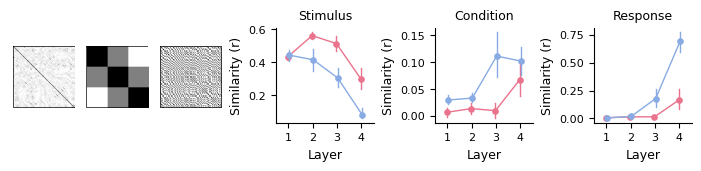

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

# parameters
pal = [(0.918, 0.451, 0.553),
       (0.537, 0.671, 0.890)]
mag = 1.2
new_pal = [(min(r * mag, 1), min(g * mag, 1), min(b * mag, 1))
           for r, g, b in pal]
# generate basic figure
# create figure
fig, axs = plt.subplot_mosaic("""
                              BBCCDDEEEFFFGGG
                              """,
                              figsize=(6.9, 1.6),
                              constrained_layout=True)
# # blank
# ax = axs["A"]
# ax.set_xticklabels([])
# ax.set_yticklabels([])
# ax.set_xticks([])
# ax.set_yticks([])
# sns.despine(left=True, bottom=True, ax=ax)

for (a, i) in zip(["B", "C", "D"], [0, 1 , 2]):
    ax = axs[a]
    data = np.squeeze(task_rdms[i].get_matrices())
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_xticks([])
    ax.set_yticks([])
    ax.imshow(data, aspect='equal', rasterized=True, cmap="gray")

    # Define the bottom-left corner, width, and height of the rectangle
    x, y = -1, -1
    width, height = 108, 108

    # Define the rectangle corners in order (closing the loop)
    x_vals = [x, x + width, x + width, x, x]
    y_vals = [y, y, y + height, y + height, y]

    # x_vals = [x, x + width]
    # y_vals = [y, y]
    # Plot the rectangle
    ax.plot(x_vals, y_vals, c="k", linewidth=0.5)  # 'b-' for blue solid line

    sns.despine(left=True, bottom=True, ax=ax)


for j, (a, target, target_label) in enumerate(zip(["E", "F", "G"],
                                                  ["visual",
                                                   "complexity",
                                                   "motor"],
                                                  ["Stimulus",
                                                   "Condition",
                                                   "Response"])):

    ax = axs[a]
    data = task_results.loc[(task_results["task_model"] == target)
                            & (task_results.layer != "average")
                            & (task_results["ann_model"] != "mlp")]
    sns.pointplot(data=data,
                  y="values",
                  x="layer",
                  hue="ann_model",
                  palette=pal,
                  linewidth=1,
                  markersize=4,
                  dodge=True,
                  zorder=10,
                  legend=False,
                  err_kws={'linewidth': 1},
                  ax=ax)

    # plot properties
    ax.tick_params(axis='both', which='major', labelsize=8)
    ax.set_xlabel("Layer", fontsize=9)
    ax.set_xticks([0, 1, 2, 3], [1, 2, 3, 4])
    ax.set_title(target_label, loc='center', fontsize=9, ha="center")
    sns.despine(ax=ax)
    ax.set_ylabel("Similarity (r)", fontsize=9)

plt.show()

# Extensive model comparison
Compare several models at init. and after training
- 2dpe
- learnable PE (0.1, a well performing model at the end of training)
- MLP

In [28]:
all_results = []
for pe_desc in ["2dpe"]:
    for epoch in [0, 4000]:
        # Get specified ANN models
        weights = get_transformer_weights(LST_puzzle_ds, pe_desc, epoch, data_dir="../processed_data/")

        # Calculate ANN RDMS
        ds_list = create_transformer_ds_from_ann(weights, n_layer, seeds)
        rdms = rsatoolbox.rdm.calc_rdm(ds_list, method=rdm_method_ann, descriptor='puzzles')

        for task_model in models:
            for ann_model in ["pe", "attn_out", "mlp"]:
                for layer in range(4):
                    rdm_input = rdms.subset('model', ann_model).subset('layer', layer)
                    results = rsatoolbox.inference.eval_fixed(task_model, rdm_input, method='corr')

                    df = pd.DataFrame()
                    df["values"] = np.squeeze(results.evaluations)
                    df["ann_model"] = "transformer"
                    df["pe"] = pe_desc
                    df["epoch"] = epoch
                    df["component"] = ann_model
                    df["layer"] = layer
                    df["task_model"] = task_model.name
                    df["seed"] = range(15)
                    all_results.append(df)

/home/lukeh/projects/LSTNN/lstnn/compare_rdms.py:214: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(
/home/lukeh/miniconda3/envs/lstann/lib/

In [29]:
import torch
from lstnn.ffn_main import FFN
import numpy as np
import torch
import torchlens as tl


def get_ffn_weights(hs, epoch, seeds):
    model_label = "ffn"
    learning_rate = 0.0001
    device = "cpu"

    # Prepare data loader for evaluation
    dataloader = torch.utils.data.DataLoader(LST_puzzle_ds,
                                                batch_size=108,
                                                shuffle=False)

    # Initialize containers to hold model outputs for all seeds
    mlp_weights_all = []   # Stores MLP outputs
    final_weights_all = [] # Stores final layer outputs

    # Loop through each seed to evaluate models with different initializations
    for seed in seeds:
        torch.manual_seed(seed)  # Set seed for reproducibility

        # Instantiate and load model with saved parameters
        model = FFN(hidden_size=hs)
        model = model.to(device=torch.device(device))

        model_file = f"../processed_data/" \
            f"model-{model_label}/" \
            f"nl-4_" \
            f"do-0_" \
            f"wd-0_" \
            f"hs-{hs}_" \
            f"lr-{learning_rate}_" \
            f"s-{seed}_" \
            f"e-{epoch}.pt"
        model.load_state_dict(torch.load(
            model_file, map_location=torch.device(device)))

    
        with torch.no_grad():
            for i, batch in enumerate(dataloader):
                test_features = batch[0]  # Get inputs from batch
                test_features = torch.flatten(
                    test_features, start_dim=1, end_dim=2)  # Flatten inputs
                test_features = test_features.to(device)
                model_history = tl.log_forward_pass(model, test_features,
                                        layers_to_save='all')
                # (0) input_1 
                # (1) flatten_1_1 
                # (2) linear_1_2 
                # (3) relu_1_3 
                # (4) linear_2_4 
                # (5) relu_2_5 
                # (6) linear_3_6 
                # (7) relu_3_7 
                # (8) linear_4_8 
                # (9) logsoftmax_1_9 
                # (10) output_1
                weights = torch.stack([
                    model_history["linear_1_2"].tensor_contents,
                    model_history["linear_2_4"].tensor_contents,
                    model_history["linear_3_6"].tensor_contents,
                    ])
                mlp_weights_all.append(weights)
                final_weights_all.append(model_history["linear_4_8"].tensor_contents)

    mlp_weights = torch.stack(mlp_weights_all).numpy()
    final_weights = torch.stack(final_weights_all).numpy()

    return {
            "mlp": mlp_weights,
            "final": final_weights,
        }

In [30]:
def create_ffn_ds_from_ann(weights, seeds):
    ds_list = []
    ann_label = "mlp"
    for layer in range(3):
        for seed in range(len(seeds)):
            data = weights[ann_label][seed, layer]
            des = {'model': ann_label, "layer": layer, "seed":seed}

            # generate information for puzzles, conditions and seeds
            puzzles = np.arange(1, 109)

            obs_des = {'puzzles': puzzles}

            ds = rsatoolbox.data.Dataset(measurements=data,
                                            descriptors=des,
                                            obs_descriptors=obs_des
                                            )
            ds_list.append(ds)
    # this gets renamed as mlp layer 3.
    ann_label = "final"
    for seed in range(len(seeds)):
        data = weights[ann_label][seed]
        des = {'model': "mlp", "layer": 3, "seed": seed}

        # generate information for puzzles, conditions and seeds
        puzzles = np.arange(1, 109)

        obs_des = {'puzzles': puzzles}

        ds = rsatoolbox.data.Dataset(measurements=data,
                                        descriptors=des,
                                        obs_descriptors=obs_des
                                        )
        ds_list.append(ds)
    return ds_list

In [31]:
seeds = [2235, 6312, 6068, 9742, 8880, 
            2197, 669, 6256, 3309, 2541, 
            8643, 7785, 195, 6914, 29]
for epoch in [0, 4000]:
    hs = 160
    #for epoch in [0, 4000]:
    # Get specified ANN models
    weights = get_ffn_weights(hs, epoch, seeds)

    # Calculate ANN RDMS
    ds_list = create_ffn_ds_from_ann(weights, seeds)
    rdms = rsatoolbox.rdm.calc_rdm(ds_list, method=rdm_method_ann, descriptor='puzzles')

    ann_model = "mlp"
    for task_model in models:
        for layer in range(4):
            rdm_input = rdms.subset('model', ann_model).subset('layer', layer)
            results = rsatoolbox.inference.eval_fixed(task_model, rdm_input, method='corr')

            df = pd.DataFrame()
            df["values"] = np.squeeze(results.evaluations)
            df["ann_model"] = "FFN"
            df["pe"] = "None"
            df["epoch"] = epoch
            df["component"] = "mlp"
            df["layer"] = layer
            df["task_model"] = task_model.name
            df["seed"] = range(15)
            all_results.append(df)
        
all_results = pd.concat(all_results)
all_results["desc"] = all_results.ann_model + "_" + all_results.pe + "_" + all_results.epoch.astype(str)

/tmp/ipykernel_2368649/901898342.py:39: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(
/tmp/ipykernel_2368649/901898342.py:39: FutureWarning

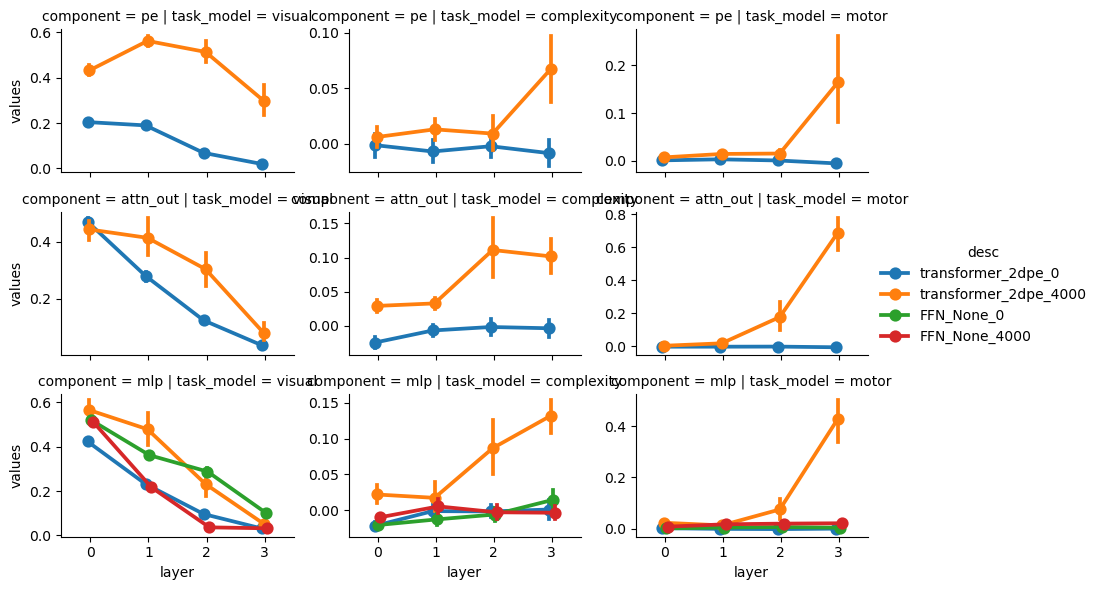

In [32]:
sns.catplot(data=all_results, y="values", x="layer", col="task_model", hue="desc", row="component", kind="point", col_order=["visual", "complexity", "motor"], sharey=False, dodge=True, height=2.0, aspect=1.5)    

In [33]:
df = all_results.copy()
df = df.loc[((df.component == "pe") | (df.component == "attn_out"))]

# Calculate summary statistics
summary_stats = df.groupby(["task_model", "ann_model","component", "epoch"])['values'].agg(['mean', 'std', 'sem']).reset_index()
summary_stats['task_model'] = pd.Categorical(summary_stats['task_model'], categories=["visual", "complexity", "motor"], ordered=True)
summary_stats = summary_stats.sort_values('task_model')
summary_stats['epoch'] = summary_stats['epoch'].replace({0: 'untrained', 4000: 'trained'})
summary_stats['component'] = summary_stats['component'].replace({"pe": 'PE', "attn_out": 'Attention'})
summary_stats[['mean', 'std', 'sem']] = summary_stats[['mean', 'std', 'sem']].round(3)

print("\nSummary statistics:")
display(summary_stats)


Summary statistics:


,task_model,ann_model,component,epoch,mean,std,sem
8,visual,transformer,Attention,untrained,0.228,0.168,0.022
9,visual,transformer,Attention,trained,0.310,0.175,0.023
10,visual,transformer,PE,untrained,0.120,0.082,0.011
11,visual,transformer,PE,trained,0.451,0.131,0.017
0,complexity,transformer,Attention,untrained,-0.009,0.023,0.003
1,complexity,transformer,Attention,trained,0.069,0.064,0.008
2,complexity,transformer,PE,untrained,-0.004,0.021,0.003
3,complexity,transformer,PE,trained,0.024,0.045,0.006
4,motor,transformer,Attention,untrained,-0.002,0.008,0.001
5,motor,transformer,Attention,trained,0.223,0.308,0.040


In [34]:
df = all_results.copy()
df = df.loc[(df.component == "mlp")]

# Calculate summary statistics
summary_stats = df.groupby(["task_model", "ann_model","component", "epoch"])['values'].agg(['mean', 'std', 'sem']).reset_index()
summary_stats['task_model'] = pd.Categorical(summary_stats['task_model'], categories=["visual", "complexity", "motor"], ordered=True)
summary_stats = summary_stats.sort_values('task_model')
summary_stats['epoch'] = summary_stats['epoch'].replace({0: 'untrained', 4000: 'trained'})
summary_stats['component'] = summary_stats['component'].replace({"pe": 'PE', "attn_out": 'Attention'})
summary_stats[['mean', 'std', 'sem']] = summary_stats[['mean', 'std', 'sem']].round(3)
#summary_stats.columns = ['temperature', 'puzzle_type', 'mean_accuracy', 'std_accuracy', 'sem_accuracy']

print("\nSummary statistics:")
display(summary_stats)


Summary statistics:


,task_model,ann_model,component,epoch,mean,std,sem
8,visual,FFN,mlp,untrained,0.318,0.153,0.020
9,visual,FFN,mlp,trained,0.199,0.198,0.026
10,visual,transformer,mlp,untrained,0.196,0.153,0.020
11,visual,transformer,mlp,trained,0.332,0.228,0.029
0,complexity,FFN,mlp,untrained,-0.006,0.023,0.003
1,complexity,FFN,mlp,trained,-0.003,0.018,0.002
2,complexity,transformer,mlp,untrained,-0.006,0.022,0.003
3,complexity,transformer,mlp,trained,0.064,0.071,0.009
4,motor,FFN,mlp,untrained,0.004,0.010,0.001
5,motor,FFN,mlp,trained,0.016,0.013,0.002


In [35]:
# Round numerical columns to 3 decimal places before saving
summary_stats[['mean', 'std', 'sem']] = summary_stats[['mean', 'std', 'sem']].round(3)

## Publication plot

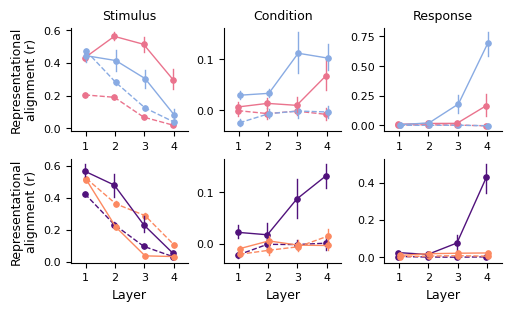

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

df = all_results.copy()
colors = plt.cm.magma(np.linspace(0, 1, 5))
pal2=colors[[1,3],:].tolist()

plt.rcParams['svg.fonttype'] = 'none'

# parameters
pal = [(0.918, 0.451, 0.553),
       (0.537, 0.671, 0.890)]
mag = 1.2
new_pal = [(min(r * mag, 1), min(g * mag, 1), min(b * mag, 1))
           for r, g, b in pal]
# generate basic figure
# create figure
fig, axs = plt.subplot_mosaic("""
                              ABC
                              DEF
                              """,
                              figsize=(5.0, 3.0),
                              constrained_layout=True)

for j, (a, target, target_label) in enumerate(zip(["A", "B", "C"],
                                                  ["visual",
                                                   "complexity",
                                                   "motor"],
                                                  ["Stimulus",
                                                   "Condition",
                                                   "Response"])):

    ax = axs[a]
    for epoch in [0, 4000]:
        data = df.loc[(df.ann_model=="transformer") 
                    & (df.component!="mlp") 
                    & (df["task_model"] == target)
                    & (df["epoch"] == epoch )]

        if epoch == 0:
            style='--'
        else:
            style='-'
        sns.pointplot(data=data,
                    y="values",
                    x="layer",
                    hue="component",
                    palette=pal,
                    linewidth=1,
                    markersize=4,
                    dodge=True,
                    linestyles=style,
                    zorder=10,
                    legend=False,
                    err_kws={'linewidth': 1},
                    ax=ax)

    # plot properties
    ax.tick_params(axis='both', which='major', labelsize=8)
    ax.set_xlabel("")
    ax.set_xticks([0, 1, 2, 3], [1, 2, 3, 4])
    ax.set_title(target_label, loc='center', fontsize=9, ha="center")
    sns.despine(ax=ax)
    if j == 0:
        ax.set_ylabel("Representational\nalignment (r)", fontsize=9)
    else:
        ax.set_ylabel("", fontsize=9)

for j, (a, target, target_label) in enumerate(zip(["D", "E", "F"],
                                                  ["visual",
                                                   "complexity",
                                                   "motor"],
                                                  ["Stimulus",
                                                   "Condition",
                                                   "Response"])):

    ax = axs[a]
    for epoch in [0, 4000]:
        data = df.loc[(df.component=="mlp") 
                    & (df["task_model"] == target)
                    & (df["epoch"] == epoch )]
        if epoch == 0:
            style='--'
        else:
            style='-'
        sns.pointplot(data=data,
                    y="values",
                    x="layer",
                    hue="ann_model",
                    palette=pal2,
                    linewidth=1,
                    markersize=4,
                    dodge=True,
                    linestyles=style,
                    zorder=10,
                    legend=False,
                    err_kws={'linewidth': 1},
                    ax=ax)

    # plot properties
    ax.tick_params(axis='both', which='major', labelsize=8)
    ax.set_xlabel("Layer", fontsize=9)
    ax.set_xticks([0, 1, 2, 3], [1, 2, 3, 4])
    #ax.set_title(target_label, loc='center', fontsize=9, ha="center")
    sns.despine(ax=ax)
    if j == 0:
        ax.set_ylabel("Representational\nalignment (r)", fontsize=9)
    else:
        ax.set_ylabel("", fontsize=9)

plt.show()